1.  **Importar Herramientas:** Se cargan las librerías necesarias: **`pandas`** para manejar la tabla de datos, **`tensorflow`** y **`keras`** para construir y gestionar la Red Neuronal, y varios módulos de **`sklearn`** para las tareas de preprocesamiento (escalado, división de datos) y evaluación.
2.  **Cargar la Tabla:** Se lee el archivo **`datasetwifis.csv`** (el dataset limpio, pivoteado y listo) y se guarda en la tabla principal llamada `df`.
3.  **Verificación:** Se comprueba que los datos (las 651 filas de lecturas y las 112 columnas de BSSids y ubicación) se hayan cargado sin problemas.

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import LabelEncoder
import io

# Configuración para evitar notación científica en numpy
np.set_printoptions(suppress=True, precision=4)

# Cargar el dataset
data_path = '/content/drive/MyDrive/Archivos .csv/datasetwifis.csv'
df = pd.read_csv(data_path)

# Mostrar las primeras filas y la información del dataset
print("DataFrame Original")
print(df.head())
print("\nInformación del DataFrame")
df.info()

DataFrame Original
   Unnamed: 0  Lect  00:01:33:88:20:54  00:0f:66:e9:ab:ec  04:f0:21:63:18:b2  \
0           0     1                0.0                0.0                0.0   
1           1     2                0.0                0.0                0.0   
2           2     3                0.0                0.0                0.0   
3           3     4                0.0                0.0                0.0   
4           4     5                0.0                0.0                0.0   

   26:39:4e:c8:ed:3c  26:60:b6:4d:5c:fc  28:77:77:dc:3d:68  28:77:77:dc:3d:a9  \
0                0.0                0.0                0.0                0.0   
1                0.0                0.0                0.0                0.0   
2              -91.0                0.0                0.0                0.0   
3              -91.0                0.0                0.0                0.0   
4              -91.0                0.0                0.0                0.0   

   2a:77:77:c

1.  **X (Entradas o Características):** Se crea la variable `x` que contiene **solo las potencias de señal Wi-Fi** (los BSSids). Estas son las **pistas** que la red neuronal usará para aprender. Se eliminan columnas innecesarias como el índice o el número de lectura.
2.  **Y (Salida o Etiqueta):** Se crea la variable `y_labels` que contiene **solo el nombre de la `Ubicacion`**. Esta es la **respuesta correcta** que el modelo debe aprender a predecir.

In [ ]:
# Eliminar las columnas que no son características
# 'Ubicacion' es la ubicación (y) y todas las MACs son (x).
x = df.drop(columns=[df.columns[0], 'Lect', 'Ubicacion'])
y_labels = df['Ubicacion']

print(f"Datos \"x\" cargados. Forma: {x.shape}")
print(f"Datos \"y\" cargados. Forma: {y_labels.shape}")

Datos "x" cargados. Forma: (651, 109)
Datos "y" cargados. Forma: (651,)


1.  **Conversión a Números:** Inicialmente, los nombres de las ubicaciones se convierten a números enteros (ej: 'Administracion' = 0, 'Aula20' = 1, etc.).
2.  **One-Hot Encoding (`to_categorical`):** Es el paso final y crucial. Estos números enteros se transforman en una **matriz binaria** (vectores de 0s y 1s). Por ejemplo, si hay 5 ubicaciones, la ubicación 'Aula20' se convierte en `[0, 1, 0, 0, 0]`. Este formato es obligatorio para los problemas de **clasificación multiclase** en Redes Neuronales.

In [ ]:
# Codificar las etiquetas de ubicación (y)
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_labels)
y_categorical = keras.utils.to_categorical(y_encoded)

print(f"Etiquetas de ubicación únicas: {encoder.classes_}")
print(f"Y codificado a categórico. Forma: {y_categorical.shape}")

Etiquetas de ubicación únicas: ['Administracion' 'Aula20' 'Aula26' 'Sala profes' 'SalaVisitas']
Y codificado a categórico. Forma: (651, 5)


1.  **Escalado Z-Score:** Se aplica el `StandardScaler`, que es una técnica que transforma los datos. Las potencias de señal (que van desde 0 hasta números negativos grandes) son ajustadas para que tengan un promedio de 0 y una desviación de 1.
2.  **Importancia:** Este paso es **vital** para las Redes Neuronales porque asegura que ninguna característica (BSSid) domine el proceso de aprendizaje debido a sus valores numéricos más grandes o más pequeños.
3.  El resultado es la matriz `x_scaled`, la versión limpia y escalada de las entradas.

In [ ]:
# Normalizar los datos de entrada (x)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

print(f"Datos x normalizados (Z-Score). Primeras filas:")
print(x_scaled[:5, :5])

Datos x normalizados (Z-Score). Primeras filas:
[[ 0.2454  0.4053  0.4995  0.3157  0.3007]
 [ 0.2454  0.4053  0.4995  0.3157  0.3007]
 [ 0.2454  0.4053  0.4995 -3.1676  0.3007]
 [ 0.2454  0.4053  0.4995 -3.1676  0.3007]
 [ 0.2454  0.4053  0.4995 -3.1676  0.3007]]


1.  **Conjunto de Entrenamiento (80%):** Los datos en `x_train` y `y_train` se usan para que la Red Neuronal **aprenda** los patrones.
2.  **Conjunto de Prueba (20%):** Los datos en `x_test` y `y_test` se reservan y se usan **solo al final** para ver qué tan bien se comporta el modelo con datos que **nunca ha visto**.
3.  **Estratificación:** Se utiliza la opción `stratify` para asegurar que la proporción de cada ubicación (ej: 20% Aula20, 10% Biblioteca) sea la misma en ambos conjuntos, garantizando una evaluación justa.

In [ ]:
# Dividir el conjunto de datos en entrenamiento y prueba (80/20)
x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"X_train. Forma: {x_train.shape}")
print(f"X_test. Forma: {x_test.shape}")
print(f"Y_train. Forma: {y_train.shape}")
print(f"Y_test. Forma: {y_test.shape}")

X_train. Forma: (520, 109)
X_test. Forma: (131, 109)
Y_train. Forma: (520, 5)
Y_test. Forma: (131, 5)


1.  **Arquitectura (`Sequential`):** Se construye una red con una estructura simple de capas apiladas:
    * **Capa de Entrada:** Recibe los 109 valores de potencia Wi-Fi.
    * **Capas Ocultas (`Dense`):** Se definen dos capas intermedias (con 8 y 4 neuronas) que procesan la información. Usan la activación **`relu`** para modelar relaciones complejas.
    * **Capa de Salida:** Tiene 5 neuronas (una por cada ubicación única). Usa la activación **`softmax`** para que las salidas sean probabilidades, indicando la ubicación más probable.
2.  **Compilación:** Se define el "cerebro" del entrenamiento:
    * **Optimizador (`adam`):** El método que la red usa para ajustar sus pesos y aprender.
    * **Función de Pérdida (`categorical_crossentropy`):** Mide el error del modelo. Es la función estándar para clasificación multiclase.

In [ ]:
# Creación y Compilación del Modelo
# Número de características de entrada
input_dim = x_train.shape[1]

# Número de clases de salida (ubicaciones)
output_dim = y_categorical.shape[1]

# Definición del modelo secuencial
model = keras.Sequential([
    keras.layers.Dense(units=8, activation='relu', input_shape=(input_dim,), name='Capa_Oculta_1'),
    keras.layers.Dense(units=4, activation='relu', name='Capa_Oculta_2'),
    keras.layers.Dense(units=output_dim, activation='softmax', name='Capa_Salida')
])

# Compilación del modelo
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # Pérdida para clasificación multiclase
    metrics=['accuracy']
)

print("Resumen del Modelo")
model.summary()

Resumen del Modelo


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Capa_Oculta_1 (Dense)           │ (None, 8)              │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Oculta_2 (Dense)           │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Salida (Dense)             │ (None, 5)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 941 (3.68 KB)

 Trainable params: 941 (3.68 KB)

 Non-trainable params: 0 (0.00 B)

1.  **Parada Temprana (`EarlyStopping`):** Se configura un sistema de seguridad. Si la precisión del modelo en la validación (`val_accuracy`) no mejora durante un cierto número de ciclos (`patience=5`), el entrenamiento se detiene automáticamente. Esto **previene el sobreajuste** (cuando el modelo memoriza los datos en lugar de aprender).
2.  **`model.fit`:** Inicia el entrenamiento. La red procesa los datos de entrenamiento a lo largo de 40 ciclos (`epochs=40`), ajustando sus pesos continuamente.
3.  **Resultado:** El modelo aprende muy rápidamente (logrando el 100% de precisión en validación antes de la época 40), lo que demuestra que las potencias de señal Wi-Fi son excelentes predictores para la ubicación.

In [ ]:
# Si 'val_accuracy' no mejora durante 5 épocas, el entrenamiento se detiene.
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

# Entrenamiento del Modelo
history = model.fit(
    x_train,
    y_train,
    epochs=40,      # Número de pasadas por el dataset
    batch_size=32,   # Tamaño de lote
    validation_split=0.15,       # No mostrar el progreso de cada época
    callbacks=[early_stopping]
)

print("Entrenamiento del modelo completado.")

Epoch 1/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.0939 - loss: 2.0177 - val_accuracy: 0.1795 - val_loss: 1.7536
Epoch 2/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2486 - loss: 1.7615 - val_accuracy: 0.3077 - val_loss: 1.5980
Epoch 3/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3096 - loss: 1.5300 - val_accuracy: 0.3462 - val_loss: 1.4623
Epoch 4/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3805 - loss: 1.3585 - val_accuracy: 0.5000 - val_loss: 1.3473
Epoch 5/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5059 - loss: 1.2129 - val_accuracy: 0.6282 - val_loss: 1.2418
Epoch 6/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6565 - loss: 1.0925 - val_accuracy: 0.6410 - val_loss: 1.1414
Epoch 7/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6973 - loss: 1.0093 - val_accuracy: 0.6795 - val_loss: 1.0493
Epoch 8/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8237 - loss: 0.8982 - val_accuracy: 0.7308 - va

1.  **Gráfica de Pérdida (Loss):** Muestra el error del modelo. Lo ideal es que la línea de pérdida caiga rápidamente para el entrenamiento y la validación.
2.  **Gráfica de Precisión (Accuracy):** Muestra el éxito del modelo. La línea debe subir rápidamente y estabilizarse cerca de 1.0 (o 100%).
3.  **Conclusión:** Estas gráficas confirman que el entrenamiento fue exitoso: la pérdida se minimizó y la precisión se maximizó sin signos de sobreajuste.

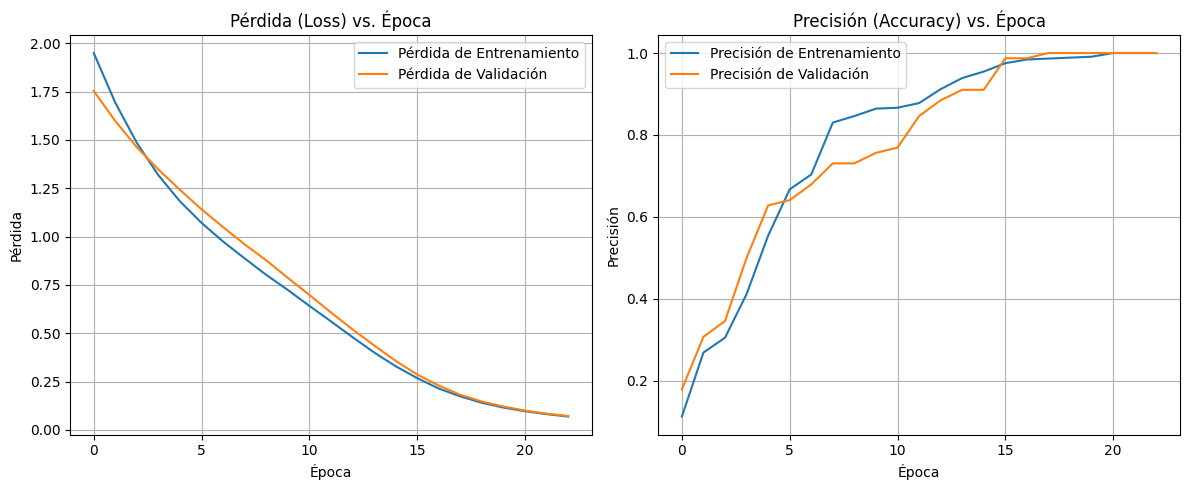

In [ ]:
## Gráficas de Entrenamiento

plt.figure(figsize=(12, 5))

# Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de Validación')
plt.title('Pérdida (Loss) vs. Época')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

# Gráfica de Precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Precisión de Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión de Validación')
plt.title('Precisión (Accuracy) vs. Época')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

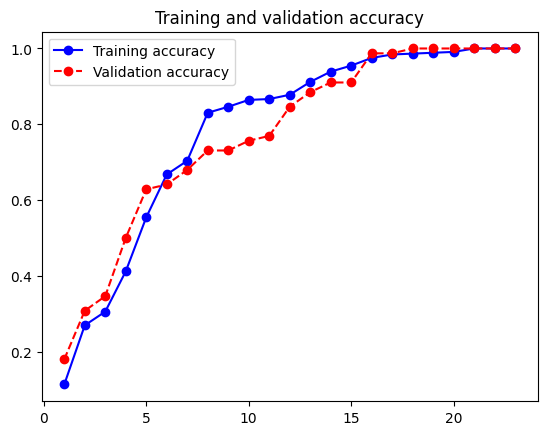

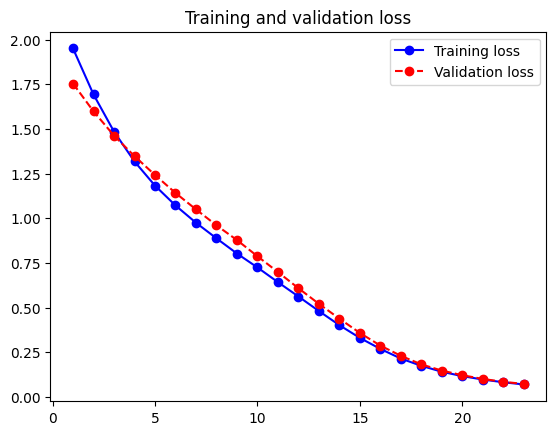

In [ ]:
def plot(history):
    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(1, len(accuracy) + 1)

    plt.plot(epochs, accuracy, "b-o", label="Training accuracy")
    plt.plot(epochs, val_accuracy, "r--o", label="Validation accuracy")
    plt.title("Training and validation accuracy")
    plt.legend()
    plt.figure()

    plt.plot(epochs, loss, "b-o", label="Training loss")
    plt.plot(epochs, val_loss, "r--o", label="Validation loss")
    plt.title("Training and validation loss")
    plt.legend()
    plt.show()

plot(history)

1.  **Predicción:** El modelo predice las ubicaciones para todos los datos de prueba.
2.  **Reporte de Clasificación:** Se genera una tabla de métricas detalladas para **cada ubicación**:
    * **Precision:** Qué tan confiable es la predicción del modelo para una ubicación específica.
    * **Recall (Exhaustividad):** Qué tan bien el modelo encuentra todas las instancias de esa ubicación.
    * **F1-Score:** Un promedio balanceado de las dos anteriores.
3.  **Precisión General:** El resultado clave, que muestra que el modelo tiene una precisión general muy alta (99.24%), confirmando que es muy bueno para predecir la ubicación.

In [ ]:
# Estadísticas de Precisión

# Predicciones en el conjunto de prueba
y_pred_proba = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1) # Obtener el índice de la clase predicha

# Convertir las etiquetas reales de prueba de One-Hot a índices
y_test_labels = np.argmax(y_test, axis=1)

# Reporte de clasificación
print("Reporte de Clasificación (Conjunto de Prueba)")
print(classification_report(y_test_labels, y_pred, target_names=encoder.classes_.astype(str), zero_division=0))

# Precisión General
accuracy = accuracy_score(y_test_labels, y_pred)
print(f"Precisión General del Modelo: {accuracy:.4f}")

Reporte de Clasificación (Conjunto de Prueba)
                precision    recall  f1-score   support

Administracion       1.00      1.00      1.00        47
        Aula20       1.00      0.96      0.98        23
        Aula26       1.00      1.00      1.00        29
   Sala profes       0.96      1.00      0.98        23
   SalaVisitas       1.00      1.00      1.00         9

      accuracy                           0.99       131
     macro avg       0.99      0.99      0.99       131
  weighted avg       0.99      0.99      0.99       131

Precisión General del Modelo: 0.9924


1.  **Matriz de Confusión:** Es una tabla gráfica que compara las ubicaciones **Reales** (filas) con las ubicaciones **Predichas** (columnas).
2.  **Aciertos:** Los números en la **diagonal principal** (de arriba a la izquierda, a abajo a la derecha) muestran el número de veces que el modelo predijo correctamente la ubicación.
3.  **Errores:** Los números fuera de la diagonal muestran los **errores de clasificación** (por ejemplo, cuando la ubicación real era 'Aula20' pero el modelo predijo 'Sala profes'). La matriz, al ser casi perfecta, tiene casi todos sus valores concentrados en la diagonal.

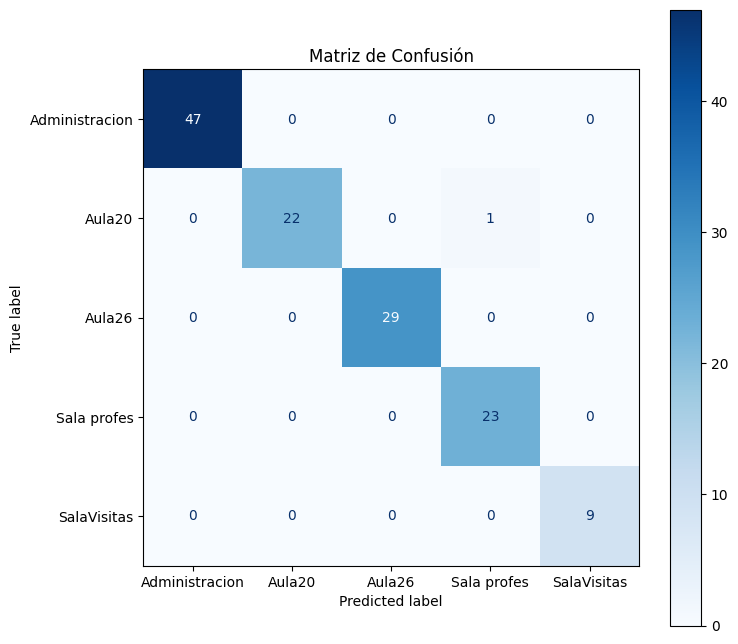

In [ ]:
# Matriz de Confusión
cm = confusion_matrix(y_test_labels, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Matriz de Confusión')
plt.show()